<a href="https://colab.research.google.com/github/sergiosuarez21/EQ3_InteligenciaArtificial_y_RedesNeuronales/blob/main/AF5_Procesamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Actividad 5: Procesamiento de conjuntos de datos en Python**

Hora: N1-N3

Reynaldo Aldape Sonora
2028750

Angel Esteban Pedraza Gomez
2097528

Sergio Daniel Suárez Aguirre 2127902

Alberto Araujo Martinez 2025718

Emilio David Cerda Salazar 2070100

--- 2. PRIMERAS FILAS DEL DATASET ORIGINAL ---
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246

Información del Dataset (antes de limpiar):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tiempo (s)        1000 non-null   int64  
 1   Distancia (cm)    970 non-null    float64
 2   Velocidad (cm/s)  970 non-null    float64
 3   Temperatura (°C)  970 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None


--- 3. DATASET LIMPIO (Sin nulos y sin velocidades negativas) ---
 

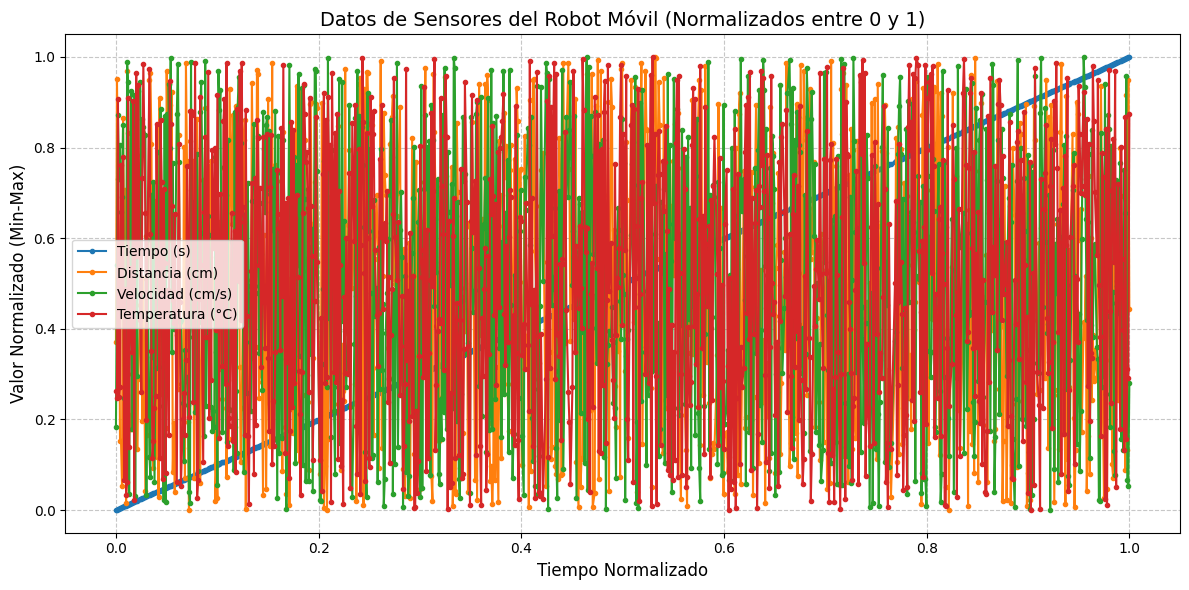

In [ ]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Cargar el dataset con pandas directamente desde el repositorio en GitHub
url = "https://raw.githubusercontent.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/main/MachineLearning/Datasets/robot_sensors.csv"
df = pd.read_csv(url)

#  Mostrar las primeras filas del dataset
print("--- 2. PRIMERAS FILAS DEL DATASET ORIGINAL ---")
print(df.head())
print("\nInformación del Dataset (antes de limpiar):")
print(df.info())
print("\n" + "="*50 + "\n")

# Limpiar los datos
# a) Eliminar filas con valores nulos
df_clean = df.dropna().copy()

# b) Filtrar valores atípicos (por ejemplo, si la velocidad es negativa)
df_clean = df_clean[df_clean['Velocidad (cm/s)'] >= 0]

print("--- 3. DATASET LIMPIO (Sin nulos y sin velocidades negativas) ---")
print(df_clean.head())
print(f"\nNúmero de filas originales: {len(df)}")
print(f"Número de filas después de la limpieza: {len(df_clean)}")
print("\n" + "="*50 + "\n")

# Normalizar los datos numéricos con Min-Max Scaling
scaler = MinMaxScaler()
# Seleccionamos las columnas a normalizar
columnas_numericas = ['Tiempo (s)', 'Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']

df_normalized = df_clean.copy()
df_normalized[columnas_numericas] = scaler.fit_transform(df_clean[columnas_numericas])

print("--- 4. PRIMERAS FILAS DEL DATASET NORMALIZADO (Valores entre 0 y 1) ---")
print(df_normalized.head())
print("\n" + "="*50 + "\n")

# Visualizar los datos normalizados usando matplotlib
plt.figure(figsize=(12, 6))

for columna in columnas_numericas:
    plt.plot(df_normalized['Tiempo (s)'], df_normalized[columna], label=columna, marker='o', markersize=3)

plt.title('Datos de Sensores del Robot Móvil (Normalizados entre 0 y 1)', fontsize=14)
plt.xlabel('Tiempo Normalizado', fontsize=12)
plt.ylabel('Valor Normalizado (Min-Max)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Mostrar la gráfica
plt.show()